In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# 1. Import necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split,ShuffleSplit,cross_validate,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression,PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score as ac,f1_score as f1
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report as cr
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# 2. Load Datasets

In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
print("Train data shape:",train_df.shape)
test_df  = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
print("Test data shape:",test_df.shape)

Train data shape: (198000, 15)
Test data shape: (102000, 14)


# 3. Performing EDA and Data Visualization

## 3.1 Basic Data Overview

### Dataset Overview

In [4]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


### Structure Overview

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


### Descriptive Statistics

In [6]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [7]:
train_df.describe(include="object")

,created_date,race,religion,gender,comment
count,198000,52577,52577,52577,197999
unique,197996,6,8,5,197842
top,2022-05-06 20:47:06.726636+00:00,none,none,none,Exactly..
freq,2,39682,38249,36161,8


**Observations:**
1. Upvote median is 1 and 75th percentile is 3, but the maximum reaches 201, showing extreme values.
2. Downvote median is 0 and 75th percentile is 1, while the maximum is 107, indicating rare high downvotes.
3. Emoticon features have median 0, meaning most comments contain no emoticons.
4. if_1 has median 0 but maximum 1860, and if_2 has median 6 but maximum 1833, showing strong outliers.

## 3.2 Missing Value Analysis

In [8]:
train_df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

**Observation:**
1. race, religion, gender have very high missing values (~145k rows).
2. comment column has only 1 missing value, negligible for analysis.
3. All other features are complete with no missing values.


## 3.3 Duplicate Data Analysis

In [9]:
# duplicate rows
print("Duplicate rows:" ,train_df.duplicated().sum())

Duplicate rows: 0


In [10]:
# duplicate comments
print("Duplicate comments:", train_df['comment'].duplicated().sum())

Duplicate comments: 157


**Observation:**
1. 157 comments are duplicated, meaning identical text appears multiple times.

## 3.4 Target Value Analysis

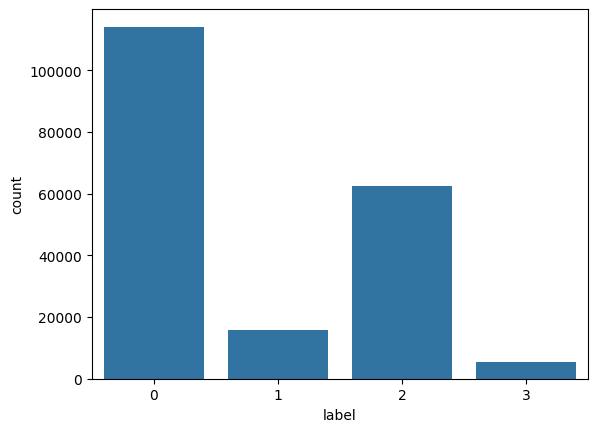

In [11]:
# check class imbalance
train_df['label'].value_counts()
train_df['label'].value_counts(normalize=True)

sns.countplot(x='label', data=train_df)
plt.show()

**Observation:**
1. Class 0 dominates the dataset, having the highest number of samples.
2. Class 2 is the second largest class, but significantly smaller than class 0.
3. Classes 1 and 3 are minority classes, indicating strong class imbalance.
4. The imbalance may require techniques like class weighting or resampling.

## 3.5 Numeric Feature Analysis

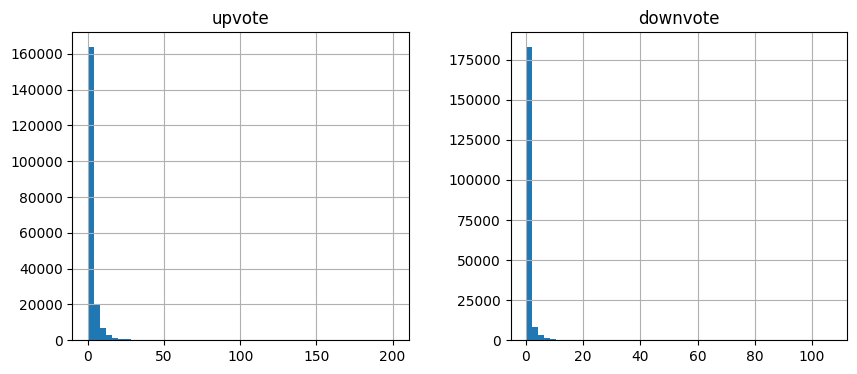

In [12]:
train_df[['upvote','downvote']].hist(bins=50, figsize=(10,4))
plt.show()

In [13]:
train_df['if_1'].value_counts().sort_index()

if_1
0       145423
4        31061
5         2691
6         6774
7           70
8            2
9           45
10       11849
11          32
12           2
249          1
250          1
1232         1
1254         1
1256         1
1257         1
1258         1
1263         1
1267         1
1271         1
1277         1
1538         1
1543         1
1545         2
1547         1
1548         1
1551         2
1553         1
1557         1
1558         1
1560         1
1566         1
1569         1
1572         1
1576         1
1581         1
1583         1
1584         1
1585         1
1767         1
1777         1
1778         1
1783         2
1800         1
1807         1
1810         1
1811         1
1814         2
1815         1
1819         1
1825         1
1827         1
1830         1
1838         1
1846         1
1848         1
1860         1
Name: count, dtype: int64

In [14]:
train_df['if_2'].value_counts().sort_index()

if_2
3           3
4       91726
5        6188
6       14558
7         366
        ...  
1633        1
1660        1
1676        1
1694        1
1833        1
Name: count, Length: 81, dtype: int64

**Observations:**
1. Upvotes and downvotes are highly right-skewed, with most comments receiving very few votes.
2. Majority of if_1 values are 0, indicating the internal condition is absent in most records.
3. if_2 values are concentrated around 4, suggesting a common internal platform state.

## 3.6 Feature vs Target Relationship

### Upvotes vs Label

<Axes: xlabel='label', ylabel='upvote'>

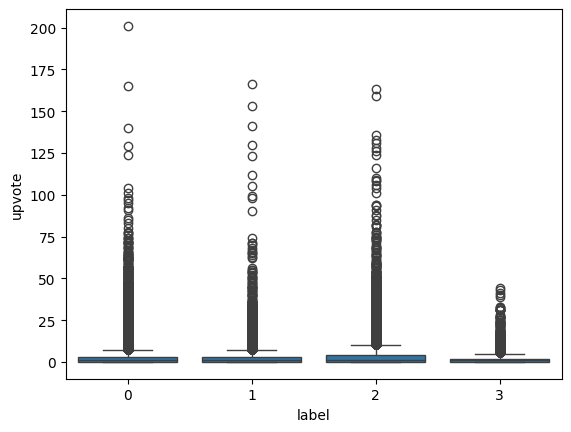

In [15]:
sns.boxplot(x='label', y='upvote', data=train_df)

### Downvotes vs Label

<Axes: xlabel='label', ylabel='downvote'>

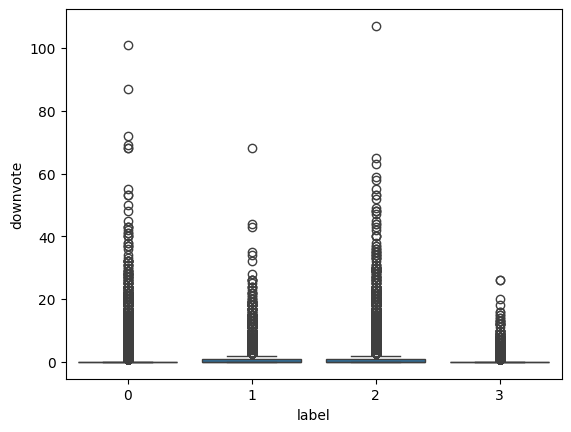

In [16]:
sns.boxplot(x='label', y='downvote', data=train_df)

**Observations:**
1. Most comments receive very few upvotes and downvotes, with medians close to zero across labels.
2. Label 2 shows slightly higher engagement, with a wider spread of votes.
3. Both features contain extreme outliers, indicating a few highly interacted comments.

## 3.7 Emoticon Feature Analysis

In [17]:
pd.crosstab(train_df['emoticon_1'], train_df['label'])

label,0,1,2,3
emoticon_1,,,,
0,97841,13651,52903,4683
1,9834,1421,5945,483
2,3266,443,1949,141
3,1345,169,768,80
4,738,97,378,30
5,379,50,192,17
6,223,30,108,13
7,144,17,60,4
8,103,10,42,7


In [18]:
pd.crosstab(train_df['emoticon_2'], train_df['label'])

label,0,1,2,3
emoticon_2,,,,
0,109963,15116,59662,5150
1,3692,656,2415,268
2,389,113,281,39
3,88,20,61,8
4,27,7,10,4
5,10,4,7,0
6,3,1,3,0
7,0,0,1,0
8,0,1,0,0


In [19]:
pd.crosstab(train_df['emoticon_3'], train_df['label'])

label,0,1,2,3
emoticon_3,,,,
0,105241,14223,56443,4928
1,6806,1272,4511,428
2,1452,282,974,69
3,384,69,288,23
4,151,42,104,12
5,55,17,54,6
6,40,7,31,1
7,19,3,18,1
8,6,1,6,1


**Observations:**
1. Most comments have no emoticons, since value 0 appears most frequently.
2. High emoticon counts are very rare in the dataset.
3. Emoticon usage looks similar across labels, so it may not strongly affect prediction.

## 3.8 Sensitive Attribute Analysis

* The features **race, religion, gender, disability** are considered to be **sensitive**.
* From missing value ananlyis, we already know that most of the values for race, relegion and gender
  are missing.
* We will see class distrubution across these categorical fields.

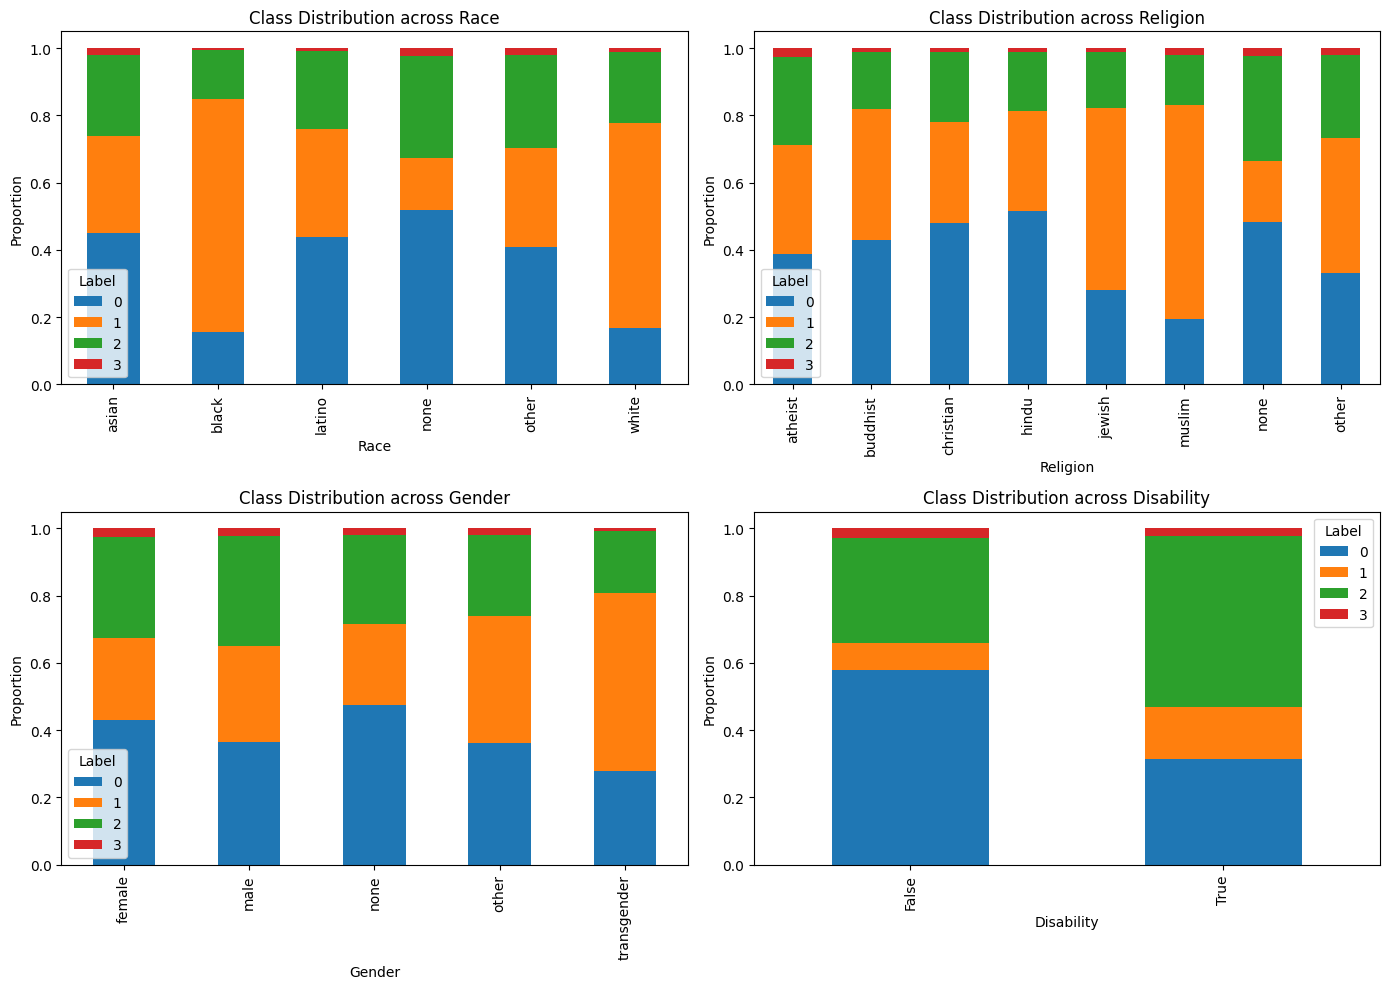

In [20]:
features = ['race', 'religion', 'gender', 'disability']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, feature in zip(axes.flatten(), features):
    pd.crosstab(train_df[feature], train_df['label'], normalize='index') \
        .plot(kind='bar', stacked=True, ax=ax)
    
    ax.set_title(f"Class Distribution across {feature.capitalize()}")
    ax.set_ylabel("Proportion")
    ax.set_xlabel(feature.capitalize())
    ax.legend(title="Label")

plt.tight_layout()
plt.show()

**Observations:**
1. Label 0 is the most common class across all sensitive groups.
2. Label 2 is the second most frequent class in most categories.
3. Labels 1 and 3 occur much less often across all groups.
4. Class distribution looks similar across categories, with no major differences.

## 3.9 Text Column Exploration



### Comment Length

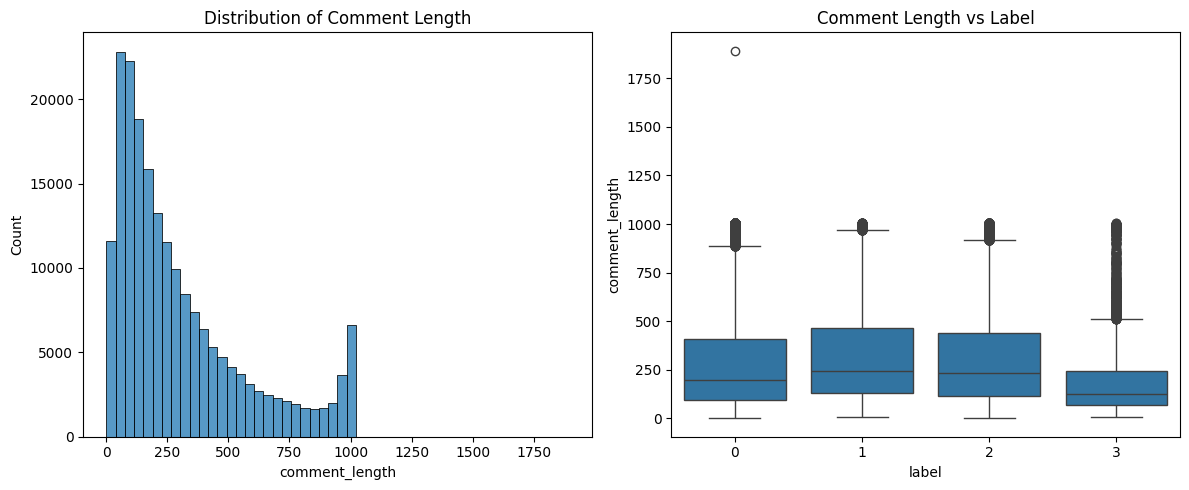

In [21]:
train_df['comment_length'] = train_df['comment'].astype(str).apply(len)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(train_df['comment_length'], bins=50, ax=ax[0])
ax[0].set_title("Distribution of Comment Length")

sns.boxplot(x='label', y='comment_length', data=train_df, ax=ax[1])
ax[1].set_title("Comment Length vs Label")

plt.tight_layout()
plt.show()

### Number of words

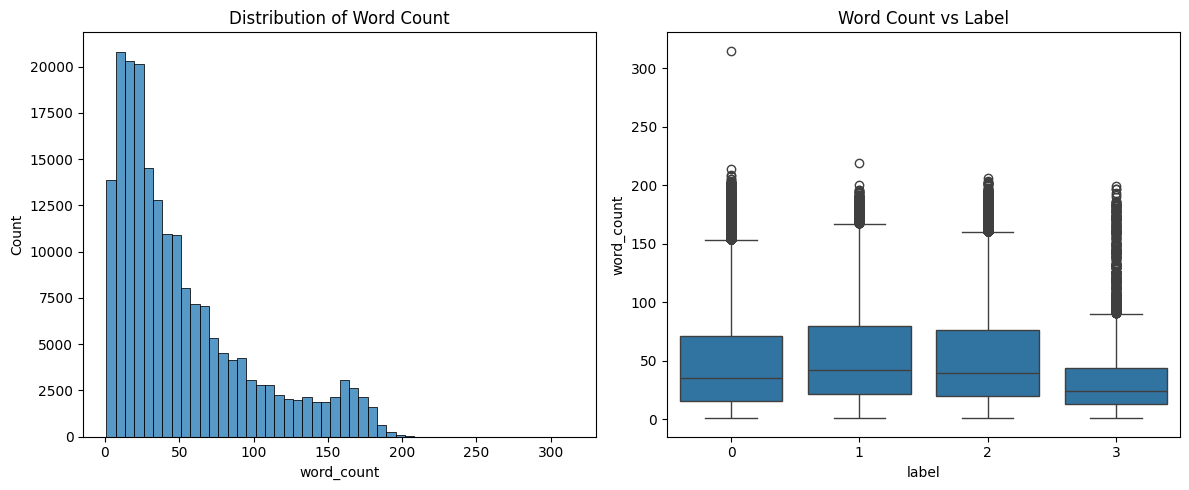

In [22]:
train_df['word_count'] = train_df['comment'].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(train_df['word_count'], bins=50, ax=ax[0])
ax[0].set_title("Distribution of Word Count")

sns.boxplot(x='label', y='word_count', data=train_df, ax=ax[1])
ax[1].set_title("Word Count vs Label")

plt.tight_layout()
plt.show()

### Most Frequent Words

In [23]:
from collections import Counter

words = " ".join(train_df['comment'].astype(str)).split()
Counter(words).most_common(20)

[('the', 465333),
 ('to', 285853),
 ('and', 237619),
 ('of', 225011),
 ('a', 209607),
 ('is', 165883),
 ('in', 139398),
 ('that', 127653),
 ('for', 98421),
 ('I', 90956),
 ('you', 85196),
 ('are', 83310),
 ('not', 66845),
 ('be', 66814),
 ('have', 64902),
 ('it', 63988),
 ('on', 62301),
 ('with', 61843),
 ('as', 53344),
 ('they', 52162)]

**Observations:**
1. Comment length and word count are right-skewed, with most comments being relatively short.
2. Labels 1 and 2 tend to have slightly longer comments and higher word counts than other classes.
3. Label 3 generally has shorter comments, indicated by lower median values.
4. There are many extreme outliers, where some comments are very long.
5. The most common words are stopwords (e.g., the, to, and, of), which dominate the text corpus.

In [24]:
train_df.drop(columns=['comment_length', 'word_count'], errors='ignore', inplace=True)

## 3.10 Time-Based Analysis

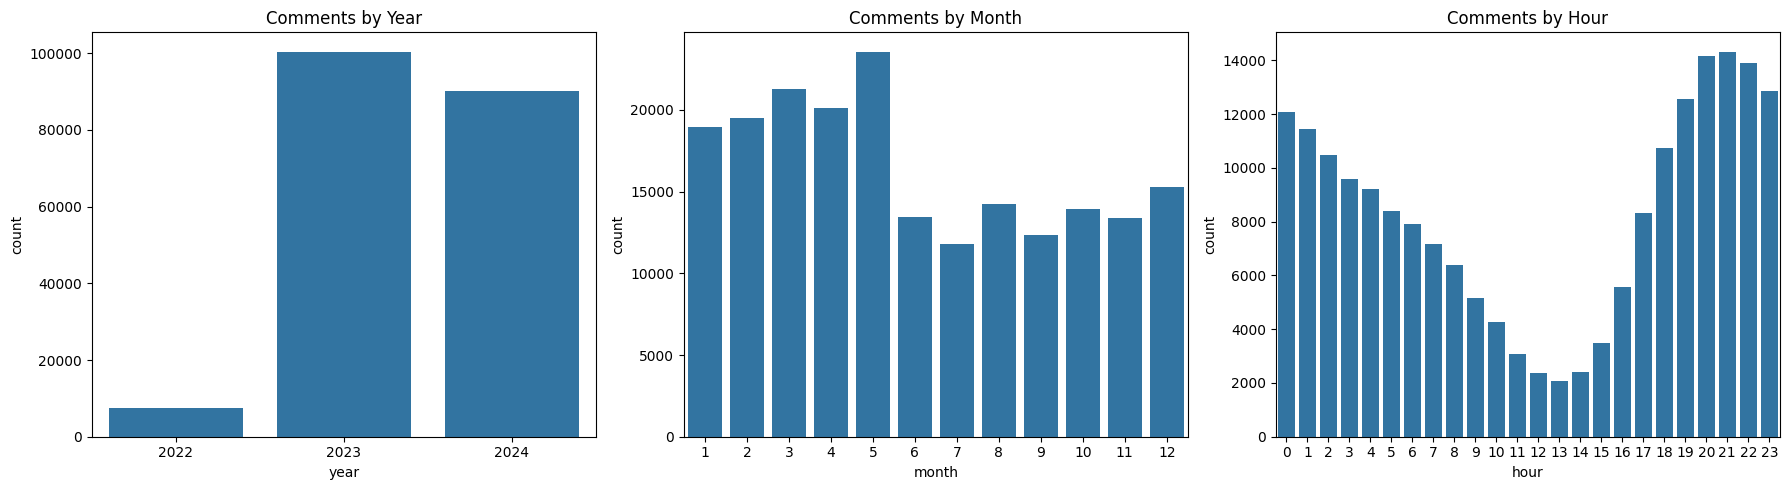

In [25]:
train_df['created_date'] = pd.to_datetime(train_df['created_date'])

train_df['year'] = train_df['created_date'].dt.year
train_df['month'] = train_df['created_date'].dt.month
train_df['hour'] = train_df['created_date'].dt.hour

fig, ax = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(x='year', data=train_df, ax=ax[0])
ax[0].set_title("Comments by Year")

sns.countplot(x='month', data=train_df, ax=ax[1])
ax[1].set_title("Comments by Month")

sns.countplot(x='hour', data=train_df, ax=ax[2])
ax[2].set_title("Comments by Hour")

plt.tight_layout()
plt.show()

**Observations:**
1. Most comments were posted in 2023 and 2024, with very few in 2022.
2. Monthly activity is fairly consistent, though some months show slightly higher comment counts.
3. Comment activity is lowest around midday (12–15 hours).
4. Most comments are posted in the evening and night hours (18–23).

In [26]:
train_df.drop(columns=['year', 'month','hour'], errors='ignore', inplace=True)

## 3.11 Correlation Analysis

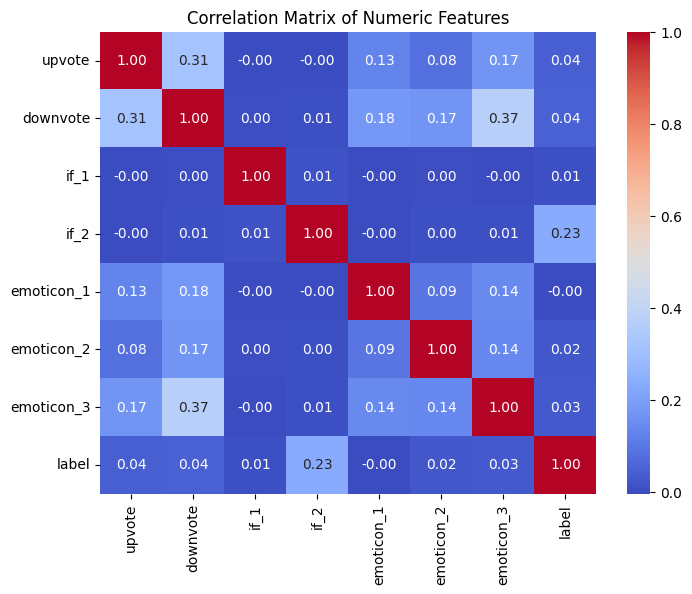

In [27]:
numeric_cols = ['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3','label']

corr = train_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

**Observations:**
1. Upvote and downvote show moderate positive correlation (~0.31), indicating higher engagement tends to increase both.
2. Downvote has the strongest correlation with emoticon_3 (~0.37), suggesting comments with this emoticon group may receive more downvotes.
3. if_2 has the highest correlation with the target label (~0.23) among numeric features.
4. Most other feature correlations are very weak, indicating low multicollinearity between variables.

## 3.12 Outlier Detection

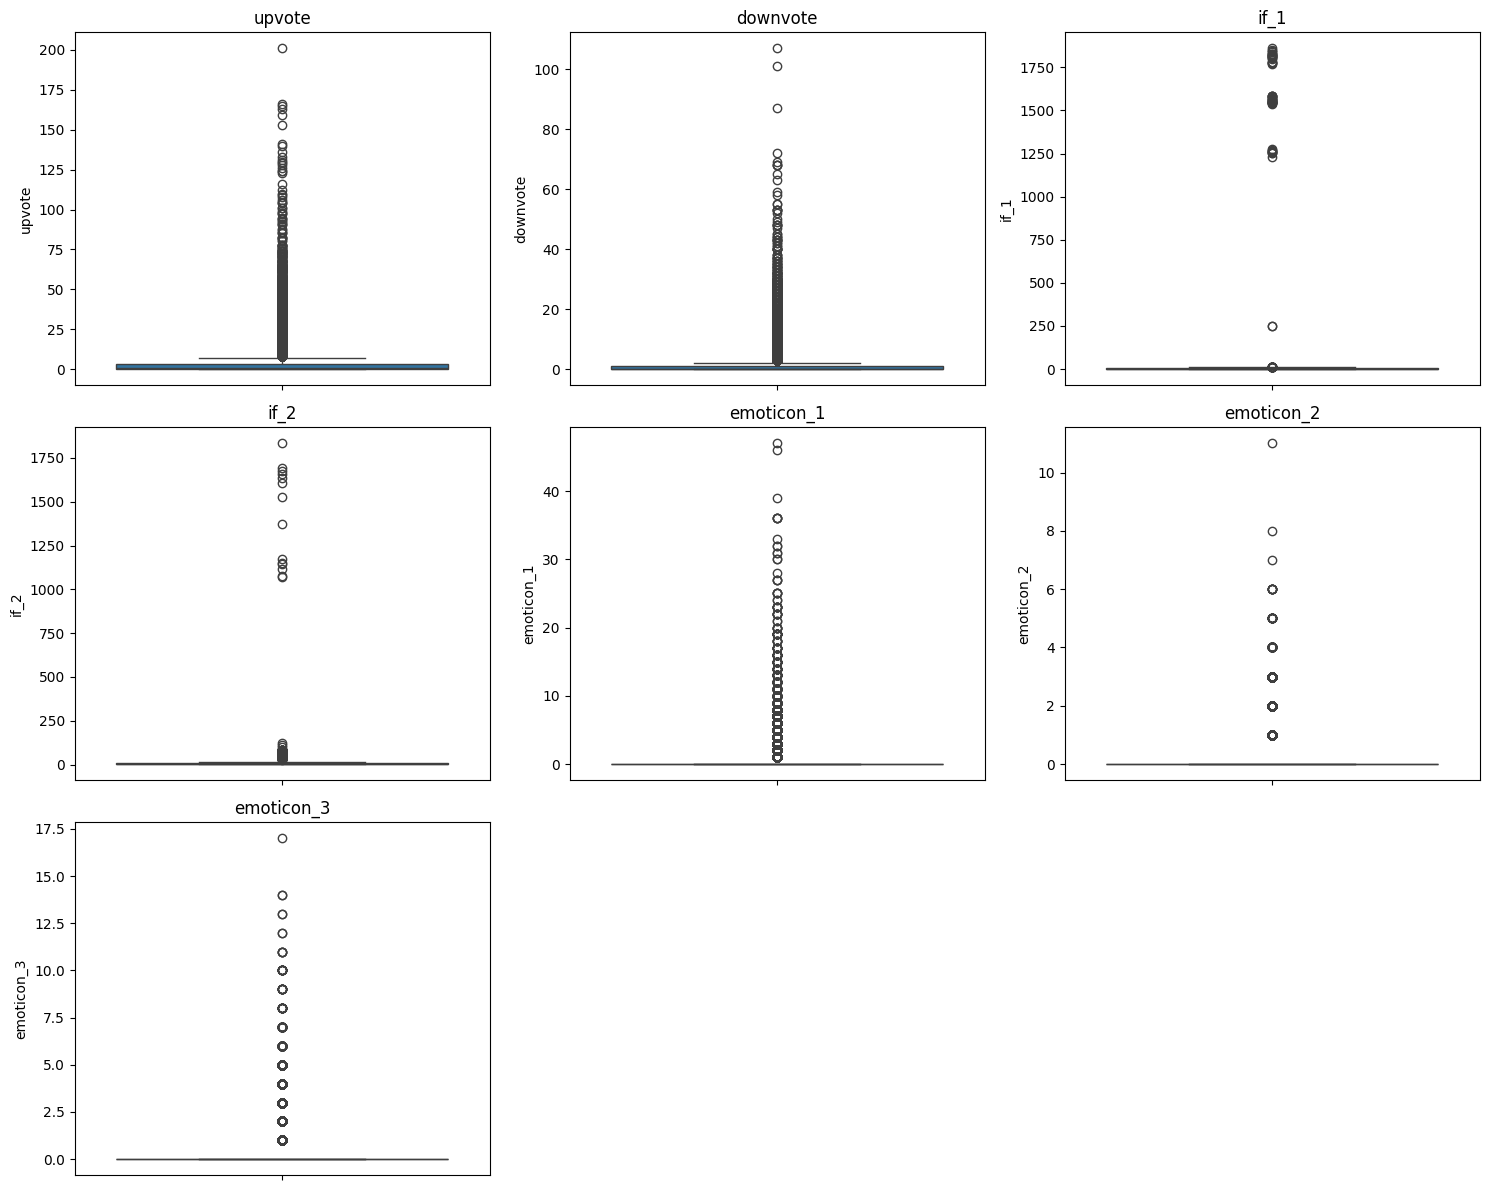

In [28]:
numeric_cols = ['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3']

fig, ax = plt.subplots(3, 3, figsize=(15,12))
ax = ax.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=train_df[col], ax=ax[i])
    ax[i].set_title(col)

# remove unused subplot spaces
for j in range(len(numeric_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

**Observations:**
1. Upvote and downvote contain many extreme outliers, with most values concentrated near zero.
2. Internal features if_1 and if_2 show very large outliers, indicating rare but extremely high values.
3. Emoticon features mostly have low values, but a few comments contain unusually high counts.
4. Overall, all numeric features are highly right-skewed with sparse extreme values.

# 4. Feature Engineering Pipeline

**Based on EDA Observations and Insights we had done the following to transform features:**

- Removed rows with missing **comment** because EDA showed text is the main information source and only one row had a missing comment.

- Filled missing values in **race, religion, and gender** with `"Unknown"` because EDA showed these columns had a very large number of missing values.

- Converted **created_date** to datetime and extract **month, dayofweek, and hour** since EDA showed comment activity varies across hours and time periods.

- Createed **timeofday** (Morning, Afternoon, Evening, Night) because EDA showed higher activity during evening and night hours.

- Created a **weekend indicator** to capture differences in posting behavior between weekdays and weekends observed in time-based analysis.

- Generated **char_count, word_count, and avg_word_len** because EDA showed comments have varying lengths and some very long comments (outliers).

- Extracted style features like **caps_ratio, exclaim_count, question_count, and punctuation_count** because punctuation and emphasis patterns are common in comment text.

- Created structure features such as **sentence_count, elongated_words, and unique_word_ratio** to capture text repetition and vocabulary diversity observed in comment analysis.

- Created engagement features **net_score, total_reactions, and vote_ratio** because EDA showed strong skewness and interaction patterns in upvotes and downvotes.

- Computed **reaction_intensity** to normalize engagement relative to comment length since longer comments may naturally receive more reactions.

- Combined emoticon counts into **total_emoticons** and create **has_emoticon** and **emoticon_density** because EDA showed emoticons are rare but occasionally appear in higher counts.

- Applied **log transformation to if_1 and if_2** because EDA revealed extremely large outliers in these internal platform features.

- Converter **disability** to numeric format to make the feature usable for machine learning models.

- Applied **log1p transformation to upvote, downvote, total_reactions, and total_emoticons** because EDA showed these features are heavily right-skewed with large outliers.

- Applied **signed log transformation to net_score** to handle both positive and negative engagement scores while reducing the impact of extreme values.

- Dropped **created_date, created_dt, and post_id** they act as identifiers or intermediate variables rather than meaningful predictive features.

In [29]:
# Drop missing comment row
train_df = train_df.dropna(subset=["comment"])

# Separate features and target
X_train=train_df.drop(["label"], axis=1)
y_train=train_df["label"]

In [30]:
def transform_features(X):

    X = X.copy()

    # Fill Missing Categorical
    X[["race","religion","gender"]] = X[["race","religion","gender"]].fillna("Unknown")

    # Datetime Features
    X["created_dt"] = pd.to_datetime(X["created_date"], errors="coerce", utc=True)

    X["month"] = X["created_dt"].dt.month
    X["dayofweek"] = X["created_dt"].dt.day_name()
    X["hour"] = X["created_dt"].dt.hour

    # Time of day
    def categorize_hour(hour):
        if 6 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 18:
            return "Afternoon"
        elif 18 <= hour < 21:
            return "Evening"
        else:
            return "Night"

    X["timeofday"] = X["hour"].apply(categorize_hour)

    # Weekend indicator
    def categorize_day(day):
        if day in ["Saturday","Sunday"]:
            return 1
        else:
            return 0

    X["weekend"] = X["dayofweek"].apply(categorize_day)

    # Text Features
    X["comment"] = X["comment"].astype(str)
    
    X["char_count"] = X["comment"].str.len()
    X["word_count"] = X["comment"].str.split().str.len()
    
    X["avg_word_len"] = X["char_count"] / X["word_count"].replace(0,1)
    
    X["caps_ratio"] = X["comment"].apply(
        lambda x: sum(c.isupper() for c in x) / max(len(x),1)
    )
    
    X["exclaim_count"] = X["comment"].str.count("!")
    
    X["question_count"] = X["comment"].str.count(r"\?")
    
    X["punctuation_count"] = X["comment"].str.count(r"[!?]")
    
    X["sentence_count"] = X["comment"].str.count(r"[.!?]")
    
    X["elongated_words"] = X["comment"].str.count(r"(.)\1{2,}")

    # Reaction Features
    X["net_score"] = X["upvote"] - X["downvote"]
    X["total_reactions"] = X["upvote"] + X["downvote"]
    X["vote_ratio"] = X["upvote"] / (X["downvote"] + 1)
    X["reaction_intensity"] = X["total_reactions"] / (X["word_count"] + 1)

    # Emoticon Features
    X["total_emoticons"] = X[["emoticon_1","emoticon_2","emoticon_3"]].sum(axis=1)
    X["has_emoticon"] = (X["total_emoticons"] > 0).astype(int)
    X["emoticon_density"] = X["total_emoticons"] / (X["word_count"] + 1)

    # Internal Hidden Features
    X["if_1"] = np.log1p(X["if_1"])
    X["if_2"] = np.log1p(X["if_2"])
    
    # Boolean to Int
    X["disability"] = X["disability"].astype(int)

    # Log Transform Skewed Features
    X["upvote"] = np.log1p(X["upvote"])
    X["downvote"] = np.log1p(X["downvote"])
    X["total_reactions"] = np.log1p(X["total_reactions"])
    X["total_emoticons"] = np.log1p(X["total_emoticons"])

    # Signed log transform for net_score
    X["net_score"] = np.sign(X["net_score"]) * np.log1p(np.abs(X["net_score"]))
    
    # Drop Identifiers
    finalX = X.drop(columns=[
        "created_date",
        "created_dt",
        "post_id"
    ])

    return finalX

X_train = transform_features(X_train)
X_test = transform_features(test_df)

# 5. Preprocessing and Feature Selection

## 5.1 Train-test split

In [31]:
stratified_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform stratified sampling
for train_index, test_index in stratified_splitter.split(X_train, y_train):
    X_train, X_val = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train, y_val = y_train.iloc[train_index], y_train.iloc[test_index]

## 5.2 Preprocessing Non-Text Features

- **Separating the text feature** from the dataset to allow independent text processing and feature extraction.

- **Applying One-Hot Encoding to categorical variables** so that they are converted into a numerical format suitable for machine learning models.

- **Standardizing numerical features using Standard Scaling** to ensure that all features have a similar scale, preventing features with larger magnitudes from dominating the model.

In [32]:
# Separate text feature
X_train_text = X_train["comment"]
X_val_text = X_val["comment"]
X_test_text = X_test["comment"]

# Remove text column from structured features
X_train_mix = X_train.drop(columns=["comment"])
X_val_mix = X_val.drop(columns=["comment"])
X_test_mix = X_test.drop(columns=["comment"])

# Pipelines
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Categorical columns
categorical_cols = [
    "race",
    "religion",
    "gender",
    "dayofweek",
    "timeofday"
]

# Binary columns
bin_cols = [
    "weekend",
    "disability",
    "has_emoticon"
]

# Numerical columns
numerical_cols = [
    "month",
    "hour",

    "upvote",
    "downvote",
    "net_score",
    "total_reactions",
    "vote_ratio",
    "reaction_intensity",

    "total_emoticons",
    "emoticon_density",

    "if_1",
    "if_2",

    "char_count",
    "word_count",
    "avg_word_len",
    "caps_ratio",

    "exclaim_count",
    "question_count",
    "punctuation_count",
    "sentence_count",
    "elongated_words"
]

# Column Transformer
ct = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols),
        ("bin", "passthrough", bin_cols)
    ]
)

# Fit and transform training data
X_train_processed = ct.fit_transform(X_train_mix)

# Transform validation data
X_val_processed = ct.transform(X_val_mix)

# Transform test data
X_test_processed = ct.transform(X_test_mix)

## 5.3 Preprocessing Text Features

- **Cleaning the comment text** by removing extra spaces and unnecessary punctuation, and converting HTML entities such as `&#39` into their corresponding characters (e.g., apostrophes).

- **Applying TF-IDF vectorization** to transform the processed text into numerical feature representations suitable for machine learning models.

In [33]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text(text):
    text = text.replace('&#39;', "'")
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Clean text
X_train_text = X_train_text.apply(clean_text)
X_val_text = X_val_text.apply(clean_text)
X_test_text = X_test_text.apply(clean_text)

# TF-IDF
tfidf = TfidfVectorizer()

X_train_text_vec = tfidf.fit_transform(X_train_text)
X_val_text_vec = tfidf.transform(X_val_text)
X_test_text_vec = tfidf.transform(X_test_text)

print("Train shape:", X_train_text_vec.shape)
print("Validation shape:", X_val_text_vec.shape)
print("Test shape:", X_test_text_vec.shape)

Train shape: (158399, 149597)
Validation shape: (39600, 149597)
Test shape: (102000, 149597)


## 5.4 Feature Selection

- **Performing feature selection using SelectKBest (chi-square test)** to retain the most informative **30,000 text features**, reducing dimensionality and improving model efficiency.

In [34]:
from sklearn.feature_selection import SelectKBest, chi2
from scipy.sparse import hstack, csr_matrix

# Select best TF-IDF features
selector = SelectKBest(chi2, k=30000)

X_train_text_k = selector.fit_transform(X_train_text_vec, y_train)
X_val_text_k = selector.transform(X_val_text_vec)
X_test_text_k = selector.transform(X_test_text_vec)

# Combine text features with structured features
finalX_train = hstack([X_train_text_k, csr_matrix(X_train_processed)]).tocsr()
finalX_val   = hstack([X_val_text_k,   csr_matrix(X_val_processed)]).tocsr()
finalX_test  = hstack([X_test_text_k,  csr_matrix(X_test_processed)]).tocsr()

print("Train shape:", finalX_train.shape)
print("Validation shape:", finalX_val.shape)
print("Test shape:", finalX_test.shape)

Train shape: (158399, 30057)
Validation shape: (39600, 30057)
Test shape: (102000, 30057)


# 6. Training the models

## 6.1 Logistic Regression


In [35]:
lr=LogisticRegression(max_iter=5000,random_state=42,n_jobs=-1)
lr.fit(finalX_train,y_train)

LogisticRegression(max_iter=5000, n_jobs=-1, random_state=42)

Training F1-score: 0.8393165593829126
Validation F1-score: 0.7967930288322815

Training Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     91338
           1       0.84      0.79      0.82     12734
           2       0.85      0.93      0.89     49952
           3       0.86      0.58      0.69      4375

    accuracy                           0.92    158399
   macro avg       0.88      0.81      0.84    158399
weighted avg       0.92      0.92      0.92    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22834
           1       0.79      0.75      0.77      3184
           2       0.84      0.92      0.88     12488
           3       0.77      0.47      0.58      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.77      0.80     39600
weighted avg       0.91      0.91      0.91     39600



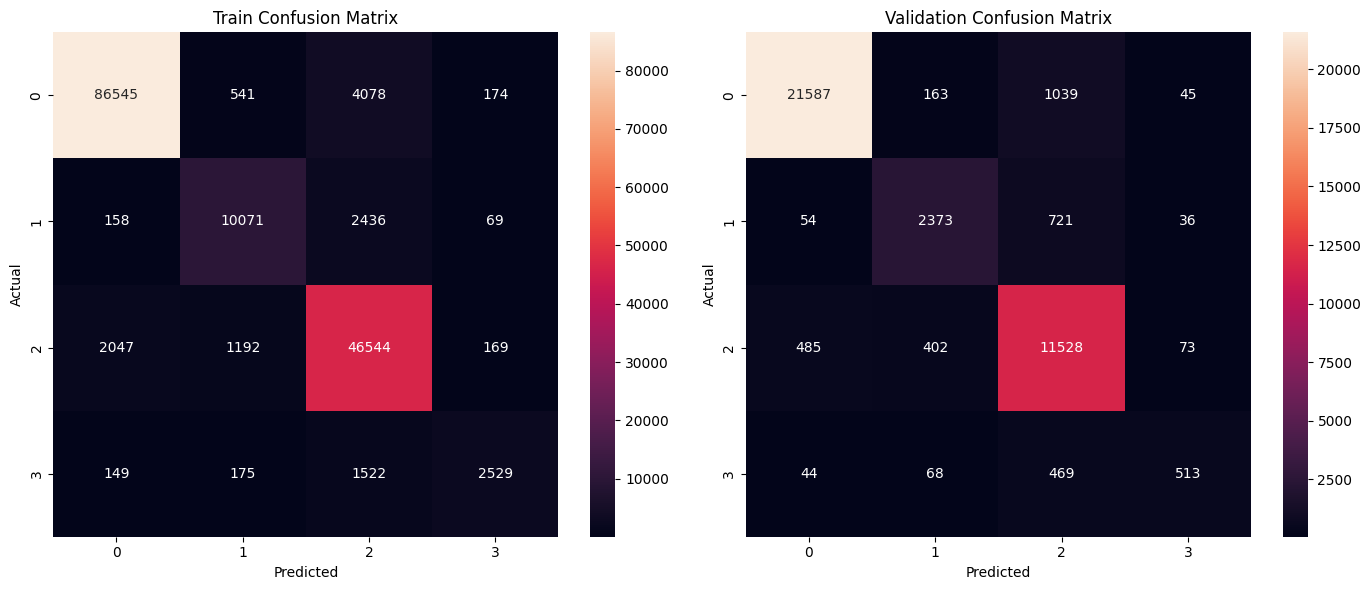

In [36]:
# Predictions
y_hat_train = lr.predict(finalX_train)
y_hat_val = lr.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that Logistic Regression achieves strong overall performance with a validation F1-score of approximately 0.80, indicating good generalization and stable learning.
2. I observed that the model struggles with class 3 (F1 ~0.58), as it is frequently misclassified into class 2, highlighting the impact of class imbalance and overlapping feature patterns.

### Hyperparameter Tuning for Logistic Regression

We are optimizing key parameters like **C** and **max_iter** to improve model performance and convergence.

In [37]:
param_dist = {
    'max_iter':[1000,2000,3000,5000],
    'C':[0.5,1,1.5,2,3]
}

lr_rs = RandomizedSearchCV(
    lr,
    param_distributions=param_dist,
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_rs.fit(finalX_train,y_train)
best_lr = lr_rs.best_estimator_
print("The best LR model using RandomizedSearchCV is :\n",best_lr)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best LR model using RandomizedSearchCV is :
 LogisticRegression(C=3, max_iter=5000, n_jobs=-1, random_state=42)


In [38]:
best_lr = LogisticRegression(max_iter=1000,random_state=42,n_jobs=-1,C=3)
best_lr.fit(finalX_train,y_train)

LogisticRegression(C=3, max_iter=1000, n_jobs=-1, random_state=42)

Training F1-score: 0.8861013918914304
Validation F1-score: 0.8050083466047951

Training Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     91338
           1       0.87      0.85      0.86     12734
           2       0.88      0.94      0.91     49952
           3       0.89      0.74      0.81      4375

    accuracy                           0.94    158399
   macro avg       0.90      0.87      0.89    158399
weighted avg       0.94      0.94      0.94    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22834
           1       0.79      0.75      0.77      3184
           2       0.85      0.92      0.88     12488
           3       0.75      0.52      0.61      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.78      0.81     39600
weighted avg       0.91      0.91      0.91     39600



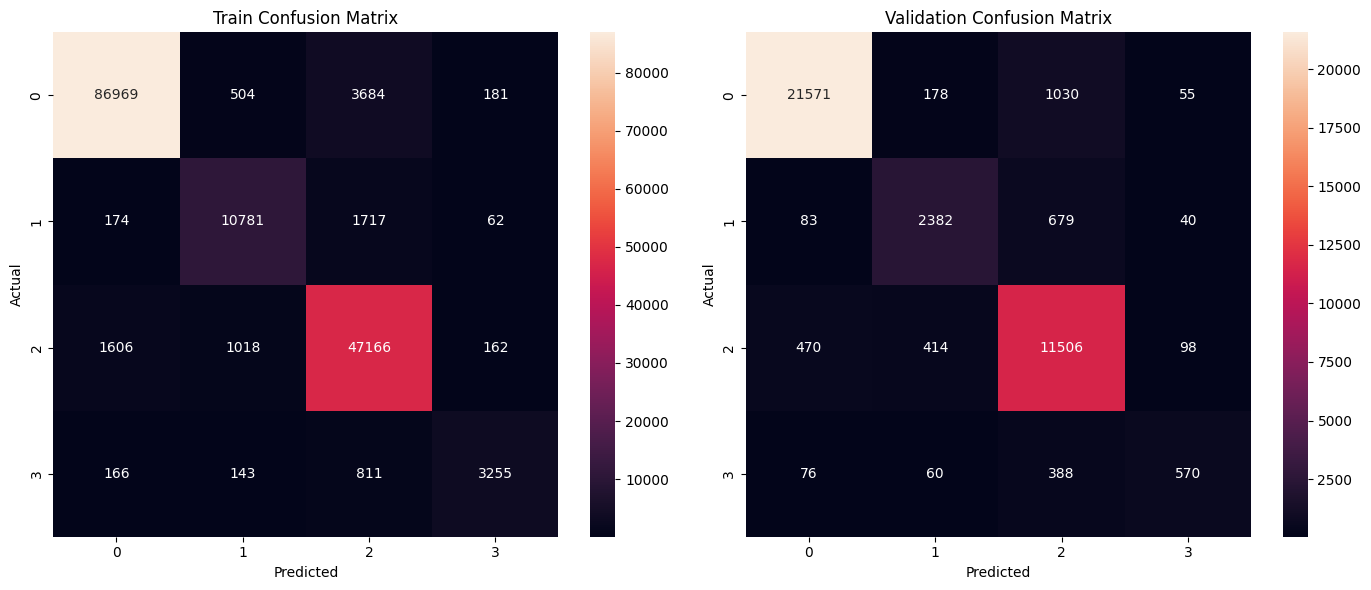

In [39]:
# Predictions
y_hat_train = best_lr.predict(finalX_train)
y_hat_val = best_lr.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the hyperparameter-tuned Logistic Regression achieves improved performance with a validation F1-score of approximately 0.80, indicating better generalization compared to the base model.
2. I observed that the model still struggles with class 3 (F1 ~0.61), although there is improvement, as it continues to be misclassified into class 2, reflecting the challenge of class imbalance.

## 6.2 SGD Classifier

In [40]:
sgd = SGDClassifier(
    loss="log_loss",
    max_iter=5000,
    early_stopping=True,
    class_weight="balanced",
    random_state=42,
    penalty="elasticnet"
)

sgd.fit(finalX_train, y_train)

SGDClassifier(class_weight='balanced', early_stopping=True, loss='log_loss',
              max_iter=5000, penalty='elasticnet', random_state=42)

Training F1-score: 0.7608282987310298
Validation F1-score: 0.7554952492848108

Training Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     91338
           1       0.70      0.73      0.71     12734
           2       0.82      0.87      0.85     49952
           3       0.71      0.43      0.53      4375

    accuracy                           0.89    158399
   macro avg       0.80      0.74      0.76    158399
weighted avg       0.89      0.89      0.89    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22834
           1       0.69      0.74      0.71      3184
           2       0.82      0.87      0.85     12488
           3       0.69      0.41      0.51      1094

    accuracy                           0.89     39600
   macro avg       0.79      0.74      0.76     39600
weighted avg       0.89      0.89      0.89     39600



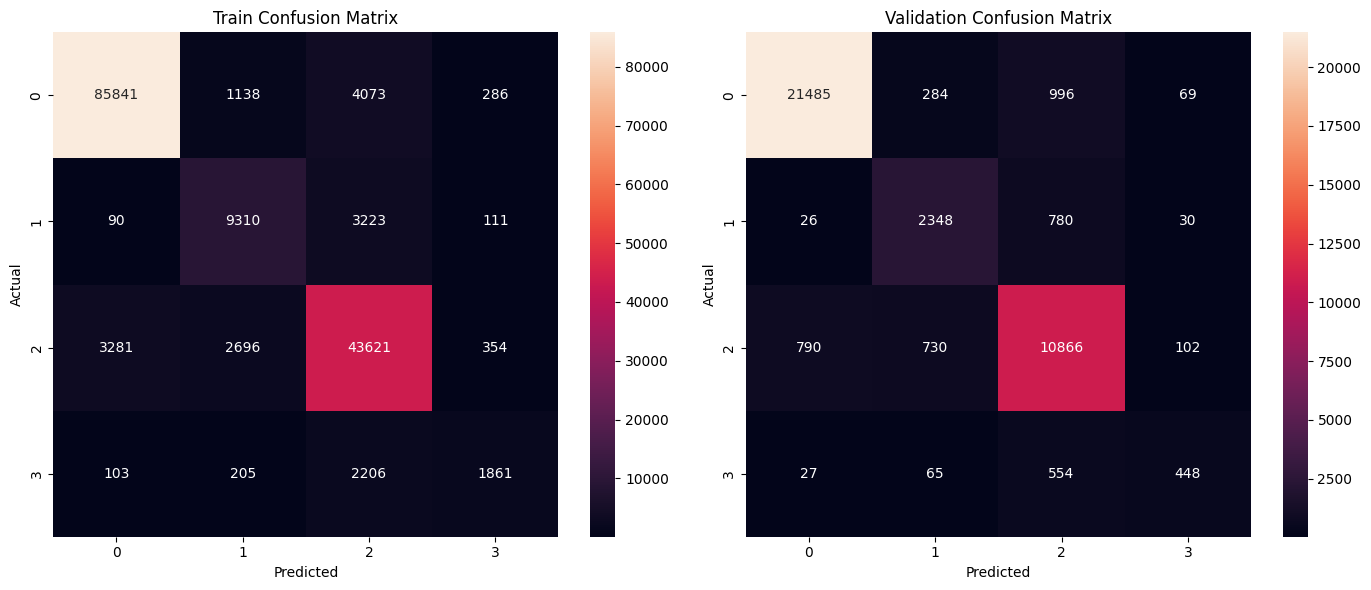

In [41]:
# Predictions
y_hat_train = sgd.predict(finalX_train)
y_hat_val = sgd.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the SGD model achieves moderate performance with a validation F1-score of approximately 0.75, indicating that it is less effective compared to other models like SVM and Logistic Regression.
2. I observed that the model struggles significantly with class 3 (F1 ~0.51), with frequent misclassification into class 2, highlighting its difficulty in handling minority class patterns and complex feature relationships.

### Hyperparameter Tuning for SGD Classifier

We are tuning **alpha** (regularization strength) and **l1_ratio** (balance between L1 and L2) to control model complexity.  
This improves performance by reducing overfitting and enhancing generalization on unseen data.

In [42]:
param_grid = {
    "alpha": [1e-6, 1e-5, 1e-4, 1e-3],
    "l1_ratio": [0.1, 0.15, 0.3, 0.5]
}

grid = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

grid.fit(finalX_train, y_train)

best_sgd = grid.best_estimator_

print("The best SGD model using GridSearchCV is :\n",best_sgd)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best SGD model using GridSearchCV is :
 SGDClassifier(alpha=1e-05, class_weight='balanced', early_stopping=True,
              l1_ratio=0.3, loss='log_loss', max_iter=5000,
              penalty='elasticnet', random_state=42)


In [43]:
best_sgd = SGDClassifier(
    alpha=1e-05,
    class_weight='balanced',
    early_stopping=True,
    l1_ratio=0.5,
    loss='log_loss',
    max_iter=5000,
    penalty='elasticnet',
    random_state=42
)

best_sgd.fit(finalX_train,y_train)

SGDClassifier(alpha=1e-05, class_weight='balanced', early_stopping=True,
              l1_ratio=0.5, loss='log_loss', max_iter=5000,
              penalty='elasticnet', random_state=42)

Training F1-score: 0.8237011034674138
Validation F1-score: 0.7916913152265974

Training Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     91338
           1       0.73      0.80      0.77     12734
           2       0.87      0.89      0.88     49952
           3       0.63      0.78      0.70      4375

    accuracy                           0.90    158399
   macro avg       0.80      0.85      0.82    158399
weighted avg       0.91      0.90      0.91    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     22834
           1       0.70      0.79      0.74      3184
           2       0.86      0.89      0.87     12488
           3       0.55      0.66      0.60      1094

    accuracy                           0.90     39600
   macro avg       0.77      0.82      0.79     39600
weighted avg       0.90      0.90      0.90     39600



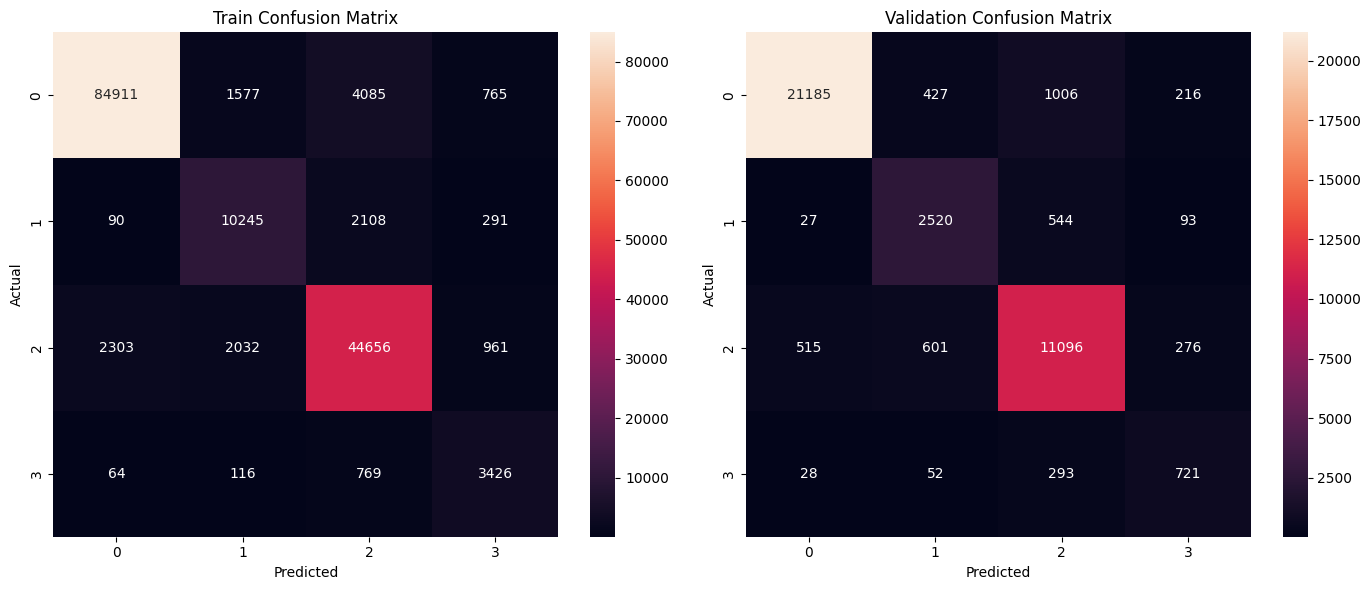

In [44]:
# Predictions
y_hat_train = best_sgd.predict(finalX_train)
y_hat_val = best_sgd.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that hyperparameter tuning improves the SGD model’s performance to a validation F1-score of approximately 0.79, indicating better learning compared to the base SGD model.
2. I observed that the model still struggles with class 3 (F1 ~0.60), as it is frequently misclassified into class 2, highlighting persistent issues with class imbalance despite tuning.

## 6.3 PassiveAggressive Classifier

In [45]:
pa = PassiveAggressiveClassifier(
    random_state=42,
    n_jobs=-1
)

pa.fit(finalX_train, y_train)

PassiveAggressiveClassifier(n_jobs=-1, random_state=42)

Training F1-score: 0.8202458224212394
Validation F1-score: 0.731446018424781

Training Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     91338
           1       0.78      0.78      0.78     12734
           2       0.84      0.91      0.87     49952
           3       0.73      0.65      0.69      4375

    accuracy                           0.90    158399
   macro avg       0.83      0.82      0.82    158399
weighted avg       0.90      0.90      0.90    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     22834
           1       0.71      0.69      0.70      3184
           2       0.80      0.87      0.84     12488
           3       0.55      0.41      0.47      1094

    accuracy                           0.87     39600
   macro avg       0.75      0.72      0.73     39600
weighted avg       0.87      0.87      0.87     39600



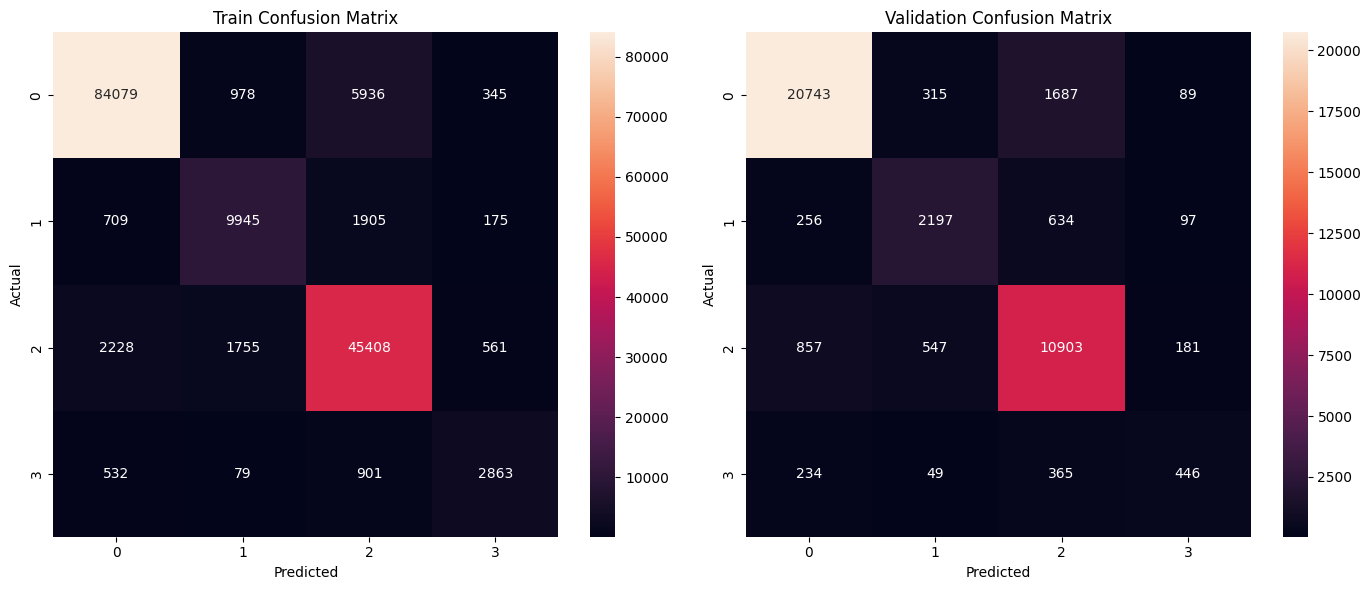

In [46]:
# Predictions
y_hat_train = pa.predict(finalX_train)
y_hat_val = pa.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the Passive Aggressive classifier achieves relatively lower performance with a validation F1-score of approximately 0.73, indicating limited learning capacity compared to other models.
2. I observed that the model performs poorly on class 3 (F1 ~0.47), with frequent misclassification into class 2, highlighting its difficulty in capturing minority class patterns.

### Hyperparameter Tuning for Passive Aggressive Classifier

We tune **C**, **loss**, and **tol** to control aggressiveness, loss behavior, and convergence criteria.  
This helps the model adapt better to data while maintaining stability and improving performance.

In [47]:
param_dist = {
    "C": [0.01, 0.1, 0.5, 1, 2],
    "loss": ["hinge", "squared_hinge"],
    "average": [True, False],
    "tol": [1e-3, 1e-4]
}

pa_rs = RandomizedSearchCV(
    pa,
    param_dist,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose = 1
)

pa_rs.fit(finalX_train, y_train)

best_pa = pa_rs.best_estimator_

print("The best PA model using RandomizedSearchCV is :\n",best_pa)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ..........................alpha=1e-06, l1_ratio=0.1; total time=   5.6s
[CV] END ..........................alpha=1e-06, l1_ratio=0.1; total time=   5.0s
[CV] END .........................alpha=1e-06, l1_ratio=0.15; total time=   7.8s
[CV] END ..........................alpha=1e-06, l1_ratio=0.3; total time=   8.5s
[CV] END ..........................alpha=1e-06, l1_ratio=0.5; total time=   6.6s
[CV] END ..........................alpha=1e-05, l1_ratio=0.1; total time=   7.8s
[CV] END .........................alpha=1e-05, l1_ratio=0.15; total time=   7.9s
[CV] END .........................alpha=1e-05, l1_ratio=0.15; total time=   6.5s
[CV] END ..........................alpha=1e-05, l1_ratio=0.3; total time=   7.3s
[CV] END ..........................alpha=1e-05, l1_ratio=0.5; total time=   4.9s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   5.1s
[CV] END ........................alpha=0.0001, l

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


The best PA model using RandomizedSearchCV is :
 PassiveAggressiveClassifier(C=0.5, average=True, loss='squared_hinge',
                            n_jobs=-1, random_state=42)


In [48]:
best_pa = PassiveAggressiveClassifier(
    C=0.5, 
    average=True, 
    max_iter=5000, 
    n_jobs=-1,
    random_state=42
)

best_pa.fit(finalX_train,y_train)

PassiveAggressiveClassifier(C=0.5, average=True, max_iter=5000, n_jobs=-1,
                            random_state=42)

Training F1-score: 0.8719714044911039
Validation F1-score: 0.7921129107058553

Training Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     91338
           1       0.86      0.82      0.84     12734
           2       0.88      0.94      0.91     49952
           3       0.89      0.68      0.77      4375

    accuracy                           0.93    158399
   macro avg       0.90      0.85      0.87    158399
weighted avg       0.93      0.93      0.93    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22834
           1       0.79      0.73      0.76      3184
           2       0.84      0.92      0.88     12488
           3       0.78      0.46      0.58      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.76      0.79     39600
weighted avg       0.91      0.91      0.90     39600



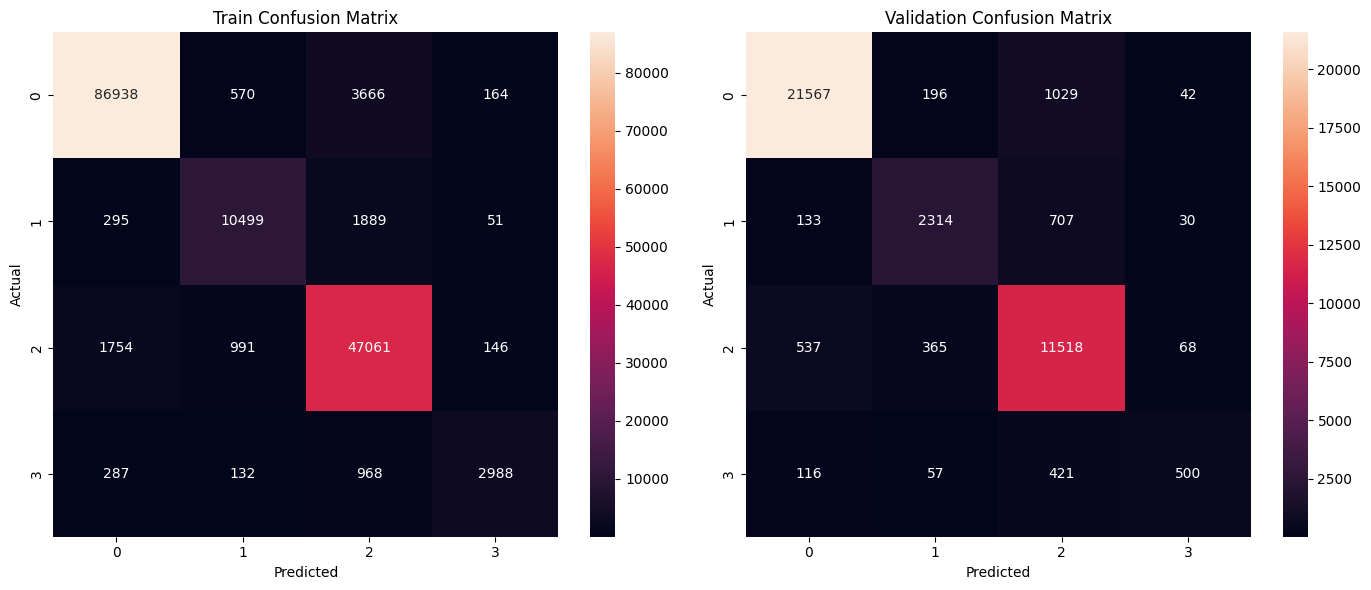

In [49]:
# Predictions
y_hat_train = best_pa.predict(finalX_train)
y_hat_val = best_pa.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that hyperparameter tuning improves the Passive Aggressive classifier’s performance to a validation F1-score of approximately 0.79, indicating better learning compared to the base model.
2. I observed that the model still struggles with class 3 (F1 ~0.58), as it is frequently misclassified into class 2, highlighting persistent issues with class imbalance.

## 6.4 SVM Classifier

In [50]:
svc = LinearSVC(
    C=1,
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

svc.fit(finalX_train, y_train)

[CV] END ..........................alpha=1e-06, l1_ratio=0.1; total time=   6.6s
[CV] END .........................alpha=1e-06, l1_ratio=0.15; total time=   8.1s
[CV] END .........................alpha=1e-06, l1_ratio=0.15; total time=   5.2s
[CV] END ..........................alpha=1e-06, l1_ratio=0.3; total time=   6.0s
[CV] END ..........................alpha=1e-06, l1_ratio=0.5; total time=   7.1s
[CV] END ..........................alpha=1e-05, l1_ratio=0.1; total time=   5.6s
[CV] END ..........................alpha=1e-05, l1_ratio=0.1; total time=   6.5s
[CV] END .........................alpha=1e-05, l1_ratio=0.15; total time=   8.2s
[CV] END ..........................alpha=1e-05, l1_ratio=0.3; total time=   6.0s
[CV] END ..........................alpha=1e-05, l1_ratio=0.5; total time=   5.7s
[CV] END ..........................alpha=1e-05, l1_ratio=0.5; total time=   6.0s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   5.0s
[CV] END ...................

LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=42)

Training F1-score: 0.9184744867066928
Validation F1-score: 0.8012533424779341

Training Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     91338
           1       0.83      0.95      0.89     12734
           2       0.91      0.94      0.93     49952
           3       0.83      0.97      0.89      4375

    accuracy                           0.94    158399
   macro avg       0.89      0.95      0.92    158399
weighted avg       0.95      0.94      0.94    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22834
           1       0.72      0.79      0.76      3184
           2       0.86      0.90      0.88     12488
           3       0.60      0.64      0.62      1094

    accuracy                           0.90     39600
   macro avg       0.79      0.82      0.80     39600
weighted avg       0.91      0.90      0.90     39600



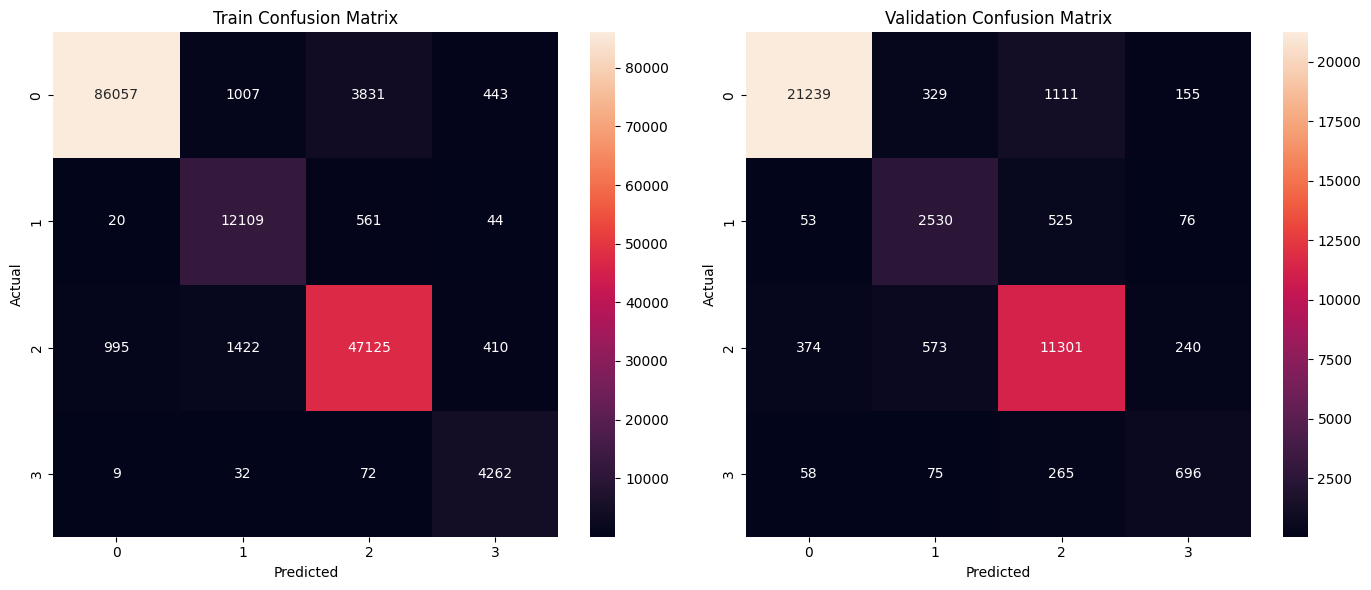

In [51]:
# Predictions
y_hat_train = svc.predict(finalX_train)
y_hat_val = svc.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the SVM model achieves strong performance with a validation F1-score of approximately 0.806, indicating effective generalization and strong classification capability.
2. I observed that the model still struggles with class 3 (F1 ~0.62), as it is frequently misclassified into class 2, highlighting the impact of class imbalance and overlapping feature patterns.

### Hyperparameter Tuning for LinearSVC

We tune **C**, **loss**, **tol**, and **max_iter** to control regularization strength and convergence behavior.  
This helps achieve a better margin, improves stability, and enhances overall model performance.

In [52]:
param_dist = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 2],
    "loss": ["hinge", "squared_hinge"],
    "tol": [1e-3, 1e-4, 1e-5],
    "max_iter": [5000, 8000, 10000]
}

svc_rs = RandomizedSearchCV(
    svc,
    param_dist,
    n_iter=20,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

svc_rs.fit(finalX_train, y_train)

best_svc = svc_rs.best_estimator_
print("The best SVC model using RandomizedSearchCV is :\n",best_svc)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

The best SVC model using RandomizedSearchCV is :
 LinearSVC(C=0.5, class_weight='balanced', max_iter=8000, random_state=42)


In [53]:
best_svc = LinearSVC(
    C=0.5, 
    class_weight='balanced',
    max_iter=8000,
    random_state=42
)

best_svc.fit(finalX_train,y_train)

LinearSVC(C=0.5, class_weight='balanced', max_iter=8000, random_state=42)

Training F1-score: 0.904477696606746
Validation F1-score: 0.805621829748456

Training Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     91338
           1       0.81      0.93      0.87     12734
           2       0.91      0.93      0.92     49952
           3       0.79      0.96      0.87      4375

    accuracy                           0.94    158399
   macro avg       0.87      0.94      0.90    158399
weighted avg       0.94      0.94      0.94    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22834
           1       0.72      0.81      0.76      3184
           2       0.86      0.91      0.88     12488
           3       0.58      0.67      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.83      0.81     39600
weighted avg       0.91      0.91      0.91     39600



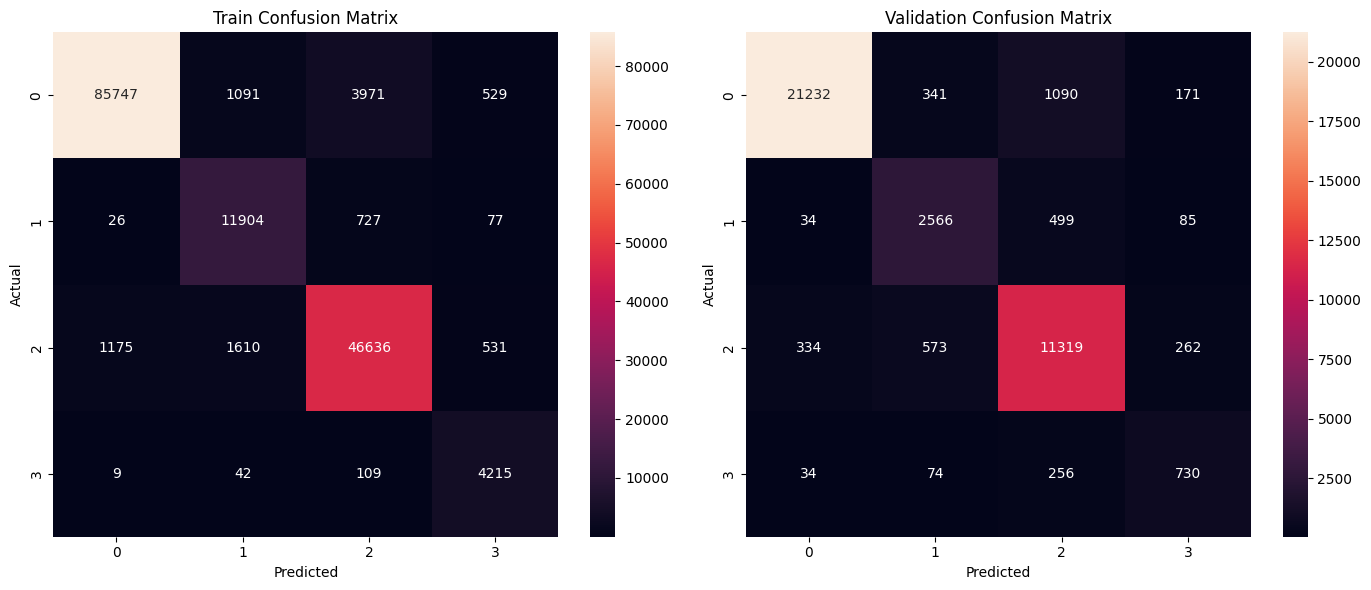

In [54]:
# Predictions
y_hat_train = best_svc.predict(finalX_train)
y_hat_val = best_svc.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the hyperparameter-tuned SVM achieves strong performance with a validation F1-score of approximately 0.806, indicating effective generalization and improved decision boundaries.
2. I observed that despite the overall performance, the model still struggles with class 3 (F1 ~0.62), as it is frequently misclassified into class 2, highlighting persistent class imbalance issues.

## 6.5 LightGBM Classifier


In [55]:
light_clf = lgb.LGBMClassifier(
    objective="multiclass",
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1,
    n_estimators=300
)

light_clf.fit(finalX_train,y_train)

LGBMClassifier(force_col_wise=True, n_estimators=300, n_jobs=-1,
               objective='multiclass', random_state=42, verbose=-1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training F1-score: 0.9169941458814986
Validation F1-score: 0.8143059931046798

Training Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     91338
           1       0.89      0.88      0.89     12734
           2       0.90      0.96      0.93     49952
           3       0.93      0.84      0.88      4375

    accuracy                           0.95    158399
   macro avg       0.93      0.91      0.92    158399
weighted avg       0.95      0.95      0.95    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.78      0.79      0.78      3184
           2       0.85      0.92      0.89     12488
           3       0.75      0.54      0.62      1094

    accuracy                           0.92     39600
   macro avg       0.84      0.80      0.81     39600
weighted avg       0.92      0.92      0.91     39600



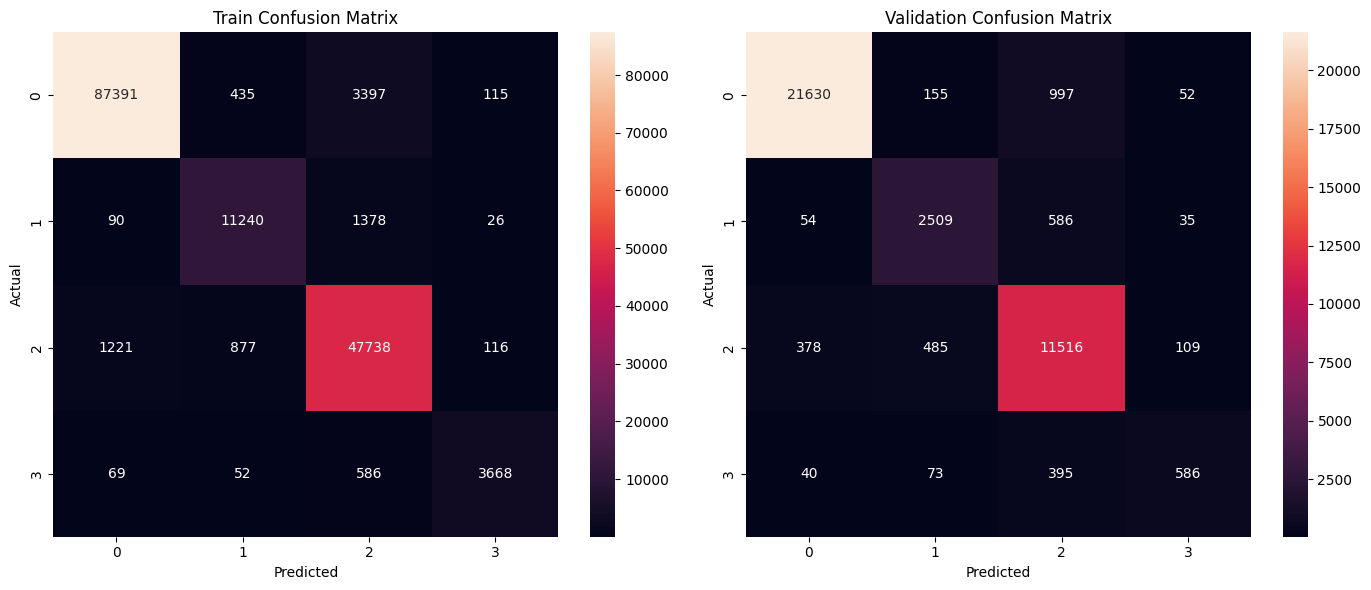

In [56]:
# Predictions
y_hat_train = light_clf.predict(finalX_train)
y_hat_val = light_clf.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the LightGBM model achieves strong performance with a validation F1-score of approximately 0.81, indicating its ability to capture complex nonlinear relationships in the data.
2. I observed that although the overall performance is good, the model still struggles with class 3 (F1 ~0.62), as it is frequently misclassified into class 2, highlighting the continued challenge of class imbalance.

## 6.6 XGBoost Classifier

In [57]:
xgb_clf = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=4
)

xgb_clf.fit(finalX_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=4,
              num_parallel_tree=None, ...)

Training F1-score: 0.8437407662849337
Validation F1-score: 0.7873284877965523

Training Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     91338
           1       0.84      0.81      0.83     12734
           2       0.86      0.94      0.90     49952
           3       0.89      0.56      0.69      4375

    accuracy                           0.93    158399
   macro avg       0.89      0.82      0.84    158399
weighted avg       0.93      0.93      0.93    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.77      0.75      0.76      3184
           2       0.84      0.92      0.88     12488
           3       0.77      0.43      0.55      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.76      0.79     39600
weighted avg       0.91      0.91      0.91     39600



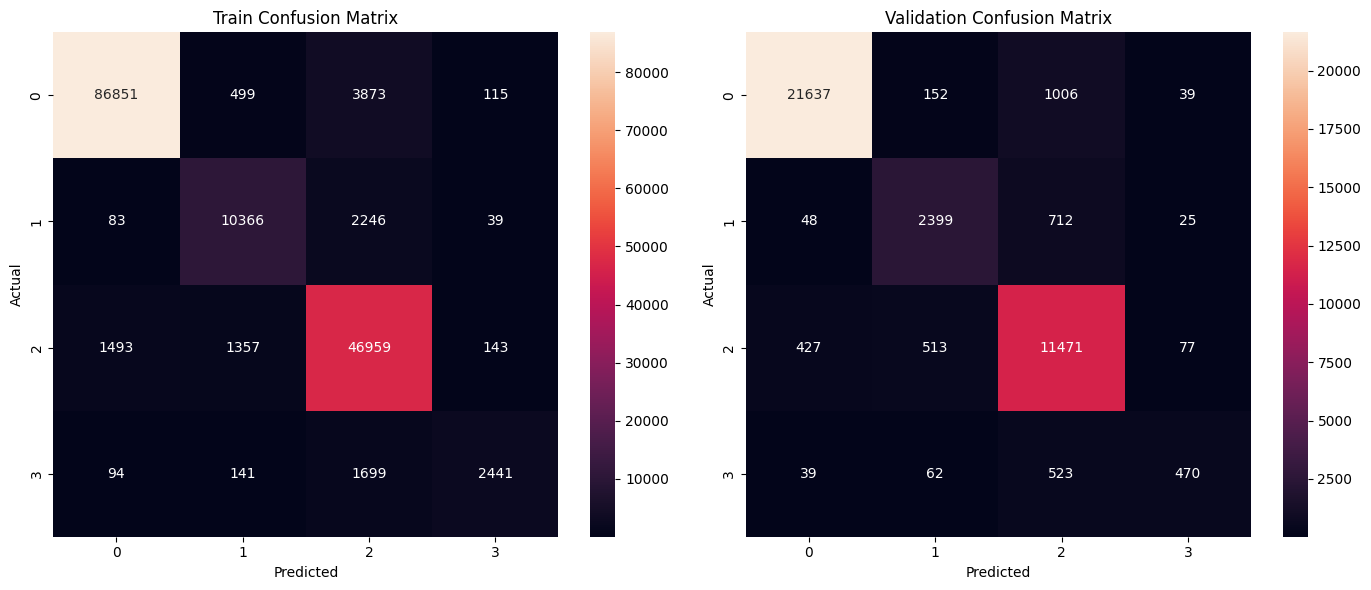

In [58]:
# Predictions
y_hat_train = xgb_clf.predict(finalX_train)
y_hat_val = xgb_clf.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the XGBoost model achieves moderate performance with a validation F1-score of approximately 0.77, indicating that it is less effective compared to other models like SVC and stacking.
2. I observed that the model struggles with class 3 (F1 ~0.55), with frequent misclassification into class 2, highlighting difficulty in capturing minority class patterns despite its complexity.

# 7. Ensemble Using Stacking Classifier

In [59]:
lr = LogisticRegression(max_iter=1000,random_state=42,n_jobs=-1,C=3)

sgd = SGDClassifier(
    alpha=1e-05,
    class_weight='balanced',
    early_stopping=True,
    l1_ratio=0.5,
    loss='log_loss',
    max_iter=5000,
    penalty='elasticnet',
    random_state=42
)

pa = PassiveAggressiveClassifier(
    C=0.5, 
    average=True, 
    max_iter=5000, 
    n_jobs=-1,
    random_state=42
)

svc = LinearSVC(
    C=0.5, 
    class_weight='balanced',
    max_iter=8000,
    random_state=42
)

lclf = lgb.LGBMClassifier(
    objective="multiclass",
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1,
    n_estimators=300
)

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=4
)

estimators = [
    
    ("sgd", sgd),
    ("pa", pa),
    ("xgb", xgb),
    ("svm", svc),
    ("lr", lr),
    ("lclf",lclf),
]

In [60]:
from sklearn.ensemble import StackingClassifier

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=lclf,
    stack_method="auto",
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack_clf.fit(finalX_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


StackingClassifier(cv=5,
                   estimators=[('sgd',
                                SGDClassifier(alpha=1e-05,
                                              class_weight='balanced',
                                              early_stopping=True, l1_ratio=0.5,
                                              loss='log_loss', max_iter=5000,
                                              penalty='elasticnet',
                                              random_state=42)),
                               ('pa',
                                PassiveAggressiveClassifier(C=0.5, average=True,
                                                            max_iter=5000,
                                                            n_jobs=-1,
                                                            random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=...
                                          max_iter=8000, random_state=42)),
                               ('lr',
                                LogisticRegression(C=3, max_iter=1000,
                                                   n_jobs=-1,
                                                   random_state=42)),
                               ('lclf',
                                LGBMClassifier(force_col_wise=True,
                                               n_estimators=300, n_jobs=-1,
                                               objective='multiclass',
                                               random_state=42, verbose=-1))],
                   final_estimator=LGBMClassifier(force_col_wise=True,
                                                  n_estimators=300, n_jobs=-1,
                                                  objective='multiclass',
                                                  random_state=42, verbose=-1),
                   n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training F1-score: 0.8984201362624622
Validation F1-score: 0.8196823190984013

Training Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     91338
           1       0.85      0.89      0.87     12734
           2       0.90      0.95      0.92     49952
           3       0.78      0.90      0.84      4375

    accuracy                           0.94    158399
   macro avg       0.88      0.92      0.90    158399
weighted avg       0.94      0.94      0.94    158399

Validation Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22834
           1       0.77      0.80      0.78      3184
           2       0.86      0.92      0.89     12488
           3       0.62      0.68      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.83      0.82     39600
weighted avg       0.92      0.91      0.91     39600



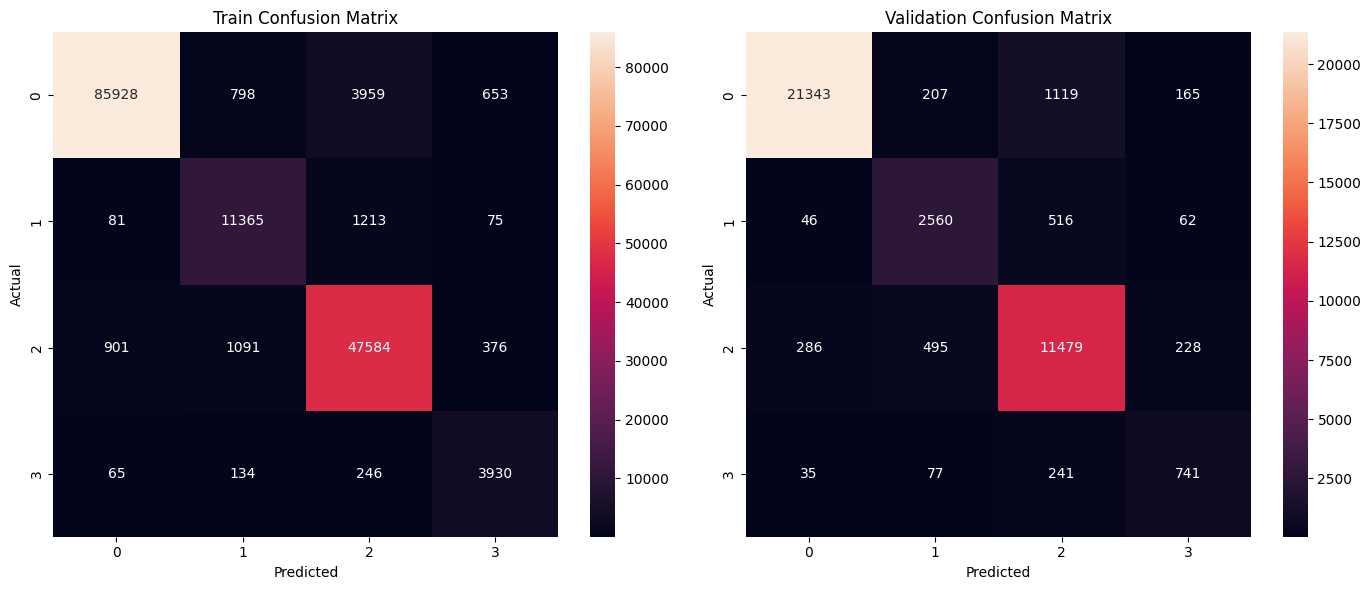

In [61]:
# Predictions
y_hat_train = stack_clf.predict(finalX_train)
y_hat_val = stack_clf.predict(finalX_val)

# Correct order: (y_true, y_pred)
train_score = f1(y_train, y_hat_train, average="macro")
val_score = f1(y_val, y_hat_val, average="macro")

print(f'Training F1-score: {train_score}\nValidation F1-score: {val_score}\n')

# Classification Reports
train_report = cr(y_train, y_hat_train)
val_report = cr(y_val, y_hat_val)

print(f'Training Report:\n{train_report}\nValidation Report:\n{val_report}')

# Confusion Matrices
train_cm = cm(y_train, y_hat_train)
val_cm = cm(y_val, y_hat_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Train Confusion Matrix ----
sns.heatmap(train_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[0])

axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- Validation Confusion Matrix ----
sns.heatmap(val_cm,
            annot=True,
            fmt='d',
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3],
            ax=axes[1])

axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the Stacking Classifier achieves strong overall performance with a validation F1-score of approximately 0.82, indicating that combining multiple models improves predictive capability.
2. I observed that the model shows improved handling of class imbalance compared to individual models, although class 3 (F1 ~0.66) still presents some misclassification challenges.

# 8. Model Comparison

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


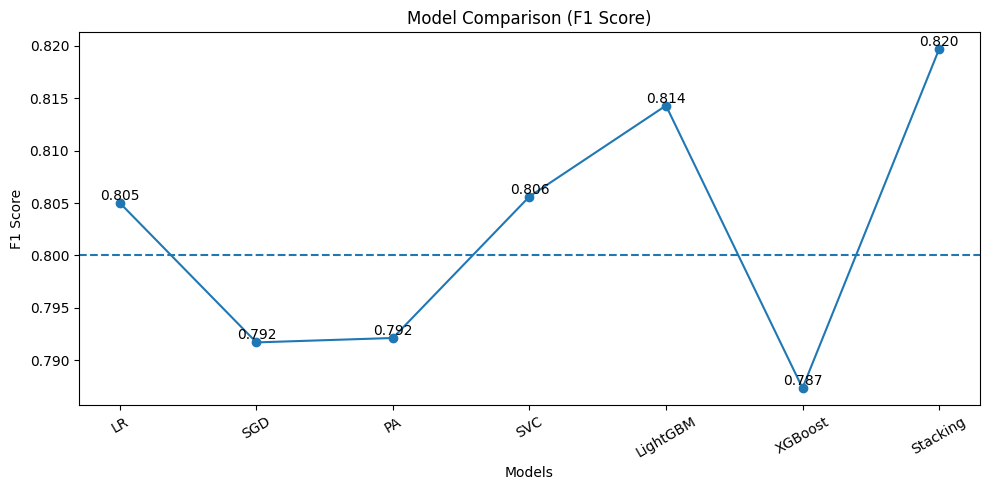

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Model names
models = ["LR", "SGD", "PA", "SVC", "LightGBM", "XGBoost", "Stacking"]

# Get predictions
preds = [
    best_lr.predict(finalX_val),
    best_sgd.predict(finalX_val),
    best_pa.predict(finalX_val),
    best_svc.predict(finalX_val),
    light_clf.predict(finalX_val),
    xgb_clf.predict(finalX_val),
    stack_clf.predict(finalX_val)
]

# Compute F1 scores (macro for multi-class)
f1_scores = [f1_score(y_val, p, average="macro") for p in preds]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(models, f1_scores, marker='o')

# Cutoff line at 0.8
plt.axhline(y=0.8,linestyle='--')

# Labels
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("Model Comparison (F1 Score)")

# Annotate values
for i, score in enumerate(f1_scores):
    plt.text(i, score, f"{score:.3f}", ha='center', va='bottom')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observations:**
1. I observed that the Stacking model achieves the highest F1-score (~0.82), outperforming all individual models and successfully crossing the 0.8 performance threshold.
2. I observed that simpler models like SGD and Passive Aggressive perform below the cutoff, while ensemble-based approaches and SVC show consistently better performance, highlighting the benefit of model combination and optimization.

# 9. Final Submission

Before submitting, train the model on the whole training dataset for better performance.

In [63]:
X_train=train_df.drop(["label"], axis=1)
y_train=train_df["label"]

# apply feature engineering
X_train = transform_features(X_train)
X_test = transform_features(test_df)

# Separate text feature
X_train_text = X_train["comment"]
X_test_text = X_test["comment"]

# Remove text column from structured features
X_train_mix = X_train.drop(columns=["comment"])
X_test_mix = X_test.drop(columns=["comment"])

# transform non-text features
X_train_processed = ct.fit_transform(X_train_mix)
X_test_processed = ct.transform(X_test_mix)

# Clean text
X_train_text = X_train_text.apply(clean_text)
X_test_text = X_test_text.apply(clean_text)

# transform text features
X_train_text_vec = tfidf.fit_transform(X_train_text)
X_test_text_vec = tfidf.transform(X_test_text)

# select best text features
X_train_text_k = selector.fit_transform(X_train_text_vec, y_train)
X_test_text_k = selector.transform(X_test_text_vec)

# Combine text features with structured features
finalX_train = hstack([X_train_text_k, csr_matrix(X_train_processed)]).tocsr()
finalX_test  = hstack([X_test_text_k,  csr_matrix(X_test_processed)]).tocsr()

stack_clf.fit(finalX_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


StackingClassifier(cv=5,
                   estimators=[('sgd',
                                SGDClassifier(alpha=1e-05,
                                              class_weight='balanced',
                                              early_stopping=True, l1_ratio=0.5,
                                              loss='log_loss', max_iter=5000,
                                              penalty='elasticnet',
                                              random_state=42)),
                               ('pa',
                                PassiveAggressiveClassifier(C=0.5, average=True,
                                                            max_iter=5000,
                                                            n_jobs=-1,
                                                            random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=...
                                          max_iter=8000, random_state=42)),
                               ('lr',
                                LogisticRegression(C=3, max_iter=1000,
                                                   n_jobs=-1,
                                                   random_state=42)),
                               ('lclf',
                                LGBMClassifier(force_col_wise=True,
                                               n_estimators=300, n_jobs=-1,
                                               objective='multiclass',
                                               random_state=42, verbose=-1))],
                   final_estimator=LGBMClassifier(force_col_wise=True,
                                                  n_estimators=300, n_jobs=-1,
                                                  objective='multiclass',
                                                  random_state=42, verbose=-1),
                   n_jobs=-1)

In [64]:
final_preds = stack_clf.predict(finalX_test)
submission = pd.DataFrame({
    "ID": range(1, len(final_preds) + 1),
    "label": final_preds
})
submission.to_csv("submission.csv", index=False)
submission.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
